# Zoneamento dos lotes
### Trabalho realizado para DIMAP-1

Esse notebook tem por objetivo obter o zoneamento de todos os lotes da cidade de São Paulo.

Para isso, vamos cruzar o polígono de cada lote com a camada de zoneamento, obtendo o zoneamento de cada lote e identificando os lotes que intersectam mais de uma zona. Para esses casos, vamos obter também o percentual da área do lote que está em cada zona, para que possamos decidir qual zona prevalesce.

Como a camada de lotes é muito grande, vamos organizar os trabalhos por setor fiscal, buscando os lotes por zona no wfs do geosampa, em seguida salvando um parquet para que cada zona.

In [36]:
from utils.wfs_geosampa import GeoSampaWFSFetcher
from utils.io.path import data_path
from utils.io.parquet import save_parquet, load_parquet
import os
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
from config import DATA_DIR

if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)

In [38]:
def get_setores_fiscais() -> gpd.GeoDataFrame:
    filename = "setores.parquet"
    subfolder = "setores"
    
    try:
        # Tenta carregar o cache local primeiro
        gdf = load_parquet(filename, subfolder, gdf=True)
        return gdf
    except (FileNotFoundError, ValueError):
        # Se não existir, instanciamos o fetcher para baixar
        fetcher = GeoSampaWFSFetcher(verbose=True)
        # Puxamos a camada completa (setor_fiscal é pequena, não precisa de loop/batch)
        data = fetcher.get_layer_data("setor_fiscal")
        
        if not data.get("features"):
            raise ValueError("A camada setor_fiscal retornou vazia do GeoSampa.")
            
        # Criamos o GeoDataFrame
        gdf = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:31983")
        
        # Salvamos para os próximos usos
        save_parquet(gdf, filename, subfolder)
        
        return gdf

In [39]:
setores = get_setores_fiscais()

In [40]:
len(setores)

312

In [41]:
setores.head()

,geometry,cd_identificador,cd_setor_fiscal,sg_fonte_original,cd_situacao,cd_identificador_original_setor
0,"POLYGON ((358237.736 7391541.277, 358234.804 7...",1,237,MDSF,1,10726675
1,"POLYGON ((323118.959 7402108.746, 323116.336 7...",3,125,MDSF,1,10916545
2,"POLYGON ((344606.69 7399688.857, 344597.18 739...",4,059,MDSF,1,10916501
3,"POLYGON ((353887.618 7389590.006, 353883.807 7...",5,194,MDSF,1,10916528
4,"POLYGON ((322001.642 7367057.032, 321996.721 7...",7,274,MDSF,1,10415133


<Axes: >

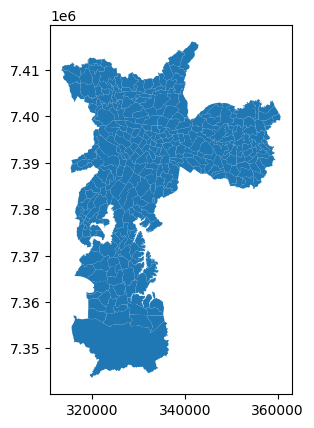

In [42]:
setores.plot()

In [43]:
setores.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Checar com equipe

Existem setores que tem uma situacao diferente, não sei se devo elimina-los

In [44]:
setores['cd_situacao'].value_counts()

cd_situacao
1    301
2     11
Name: count, dtype: int64

In [45]:
setores[setores['cd_situacao']==2]

,geometry,cd_identificador,cd_setor_fiscal,sg_fonte_original,cd_situacao,cd_identificador_original_setor
6,"POLYGON ((324896.092 7369671.323, 324881.609 7...",14,266,MDSF,2,10916538
70,"POLYGON ((325756.994 7370199.578, 325753.355 7...",138,178,MDSF,2,10916574
90,"POLYGON ((321795.022 7403423.614, 321794.923 7...",170,105,MDSF,2,10916443
91,"POLYGON ((320682.688 7400576.989, 320683.046 7...",171,105,MDSF,2,10916443
105,"POLYGON ((321522.817 7404501.449, 321522.125 7...",197,209,MDSF,2,10916546
124,"POLYGON ((319442.44 7402302.364, 319422.856 74...",224,124,MDSF,2,10916442
166,"POLYGON ((354768.493 7387197.676, 354753.193 7...",297,251,MDSF,2,10124169
212,"POLYGON ((352415.508 7386791.687, 352416.687 7...",411,252,MDSF,2,10916515
232,"POLYGON ((322175.344 7404353.213, 322175.429 7...",468,188,MDSF,2,10916567
236,"POLYGON ((352609.883 7399100.634, 352600.762 7...",477,140,MDSF,2,10916569


<Axes: >

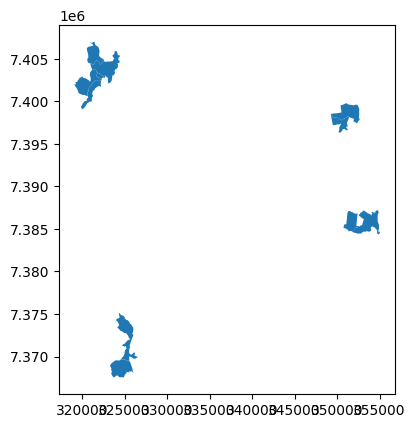

In [46]:
setores[setores['cd_situacao']==2].plot()

In [47]:
setores['cd_setor_fiscal'].duplicated().sum()

np.int64(3)

A questoa da duplicacao parece que nao tem a ver com o cd_situacao porque tem duplicados na situacao 1

In [48]:
setores[setores['cd_setor_fiscal'].duplicated(keep=False)]

,geometry,cd_identificador,cd_setor_fiscal,sg_fonte_original,cd_situacao,cd_identificador_original_setor
90,"POLYGON ((321795.022 7403423.614, 321794.923 7...",170,105,MDSF,2,10916443
91,"POLYGON ((320682.688 7400576.989, 320683.046 7...",171,105,MDSF,2,10916443
103,"POLYGON ((318568.705 7378576.106, 318562.369 7...",195,179,MDSF,1,10415141
180,"POLYGON ((339308.668 7406064.913, 339304.676 7...",320,198,MDSF,1,10415122
233,"POLYGON ((337591.597 7406149.62, 337578.013 74...",470,198,MDSF,1,10415121
298,"POLYGON ((318278.704 7376567.087, 318295.185 7...",590,179,MDSF,1,10415142


Na duvida vou dar melt e manter um multipoligono para cada

In [49]:
setores = setores[['geometry', 'cd_setor_fiscal']].dissolve(by='cd_setor_fiscal').reset_index()

In [50]:
setores.head()

,cd_setor_fiscal,geometry
0,001,"POLYGON ((333937.342 7396441.587, 333847.425 7..."
1,002,"POLYGON ((334412.036 7395892.835, 334406.703 7..."
2,003,"POLYGON ((335610.397 7394186.561, 335610.722 7..."
3,004,"POLYGON ((335139.811 7393703.854, 335148.071 7..."
4,005,"POLYGON ((332833.006 7395001.553, 332832.949 7..."


In [51]:
setores['cd_setor_fiscal'].duplicated().any()

np.False_

In [52]:
codigos_setores = set(setores['cd_setor_fiscal'].unique())

In [53]:
geosampa = GeoSampaWFSFetcher(verbose=True)
lotes_gen = geosampa('lote_cidadao', cql_filter="cd_setor_fiscal='001'")
lotes_setor = []
for lote in lotes_gen:
    lotes_setor.extend(lote)
len(lotes_setor)

Fetching data at url https://wfs.geosampa.prefeitura.sp.gov.br/geoserver/geoportal/wfs with parameters: {'service': 'WFS', 'version': '1.0.0', 'request': 'GetFeature', 'typeName': 'geoportal:lote_cidadao', 'outputFormat': 'application/json', 'startIndex': 0, 'cql_filter': "cd_setor_fiscal='001'"}


1927

In [54]:
geosampa.last_resp_metadata

{'type': 'FeatureCollection',
 'totalFeatures': 1927,
 'numberMatched': 1927,
 'numberReturned': 1927,
 'timeStamp': '2026-04-14T18:26:56.273Z',
 'crs': {'type': 'name',
  'properties': {'name': 'urn:ogc:def:crs:EPSG::31983'}}}

In [55]:
gdf_teste = gpd.GeoDataFrame.from_features(lotes_setor, crs="EPSG:31983")
gdf_teste.head()

,geometry,cd_identificador,cd_identificador_original_lote,cd_setor_fiscal,cd_tipo_quadra,tx_tipo_quadra,cd_quadra_fiscal,cd_subquadra_fiscal,cd_condominio,cd_tipo_lote,...,cd_logradouro,nm_logradouro_completo,cd_numero_porta,tx_complemento_endereco,tx_situ_lote,cd_tipo_uso_imovel,dc_tipo_uso_imovel,cd_tipo_terreno_imovel,qt_area_terreno,qt_area_construida
0,"POLYGON ((333481.928 7395280.809, 333483.792 7...",1957367,8800263,001,F,FISCAL,077,None,00,F,...,029505,R CAVLH BASILIO JAFET,130,E 134,ATIVO,40,Não residencial,1.0,136.0,320.0
1,"POLYGON ((333481.928 7395280.809, 333475.14 73...",1957368,8800271,001,F,FISCAL,077,None,00,F,...,029505,R CAVLH BASILIO JAFET,128,NaN,ATIVO,40,Não residencial,2.0,180.0,430.0
2,"POLYGON ((333509.8 7395592.7, 333507.61 739556...",1957478,8800506,001,F,FISCAL,051,None,00,F,...,002755,R COMEN AFONSO KHERLAKIAN,123,/125,ATIVO,40,Não residencial,1.0,183.0,316.0
3,"POLYGON ((333556.19 7395590.256, 333538.407 73...",1957490,8800154,001,F,FISCAL,052,None,00,F,...,061360,R BR DE DUPRAT,286,290 292 296 300,ATIVO,31,Não residencial,2.0,414.0,1035.0
4,"POLYGON ((333338.843 7396489.965, 333336.849 7...",1957502,8800542,001,F,FISCAL,003,None,02,F,...,189936,AV TIRADENTES,258 262,NaN,NaN,XX,Condomínio,99.0,283.0,NaN


In [56]:
gdf_teste.columns

Index(['geometry', 'cd_identificador', 'cd_identificador_original_lote',
       'cd_setor_fiscal', 'cd_tipo_quadra', 'tx_tipo_quadra',
       'cd_quadra_fiscal', 'cd_subquadra_fiscal', 'cd_condominio',
       'cd_tipo_lote', 'tx_tipo_lote', 'cd_lote', 'cd_situacao',
       'cd_digito_sql', 'cd_logradouro', 'nm_logradouro_completo',
       'cd_numero_porta', 'tx_complemento_endereco', 'tx_situ_lote',
       'cd_tipo_uso_imovel', 'dc_tipo_uso_imovel', 'cd_tipo_terreno_imovel',
       'qt_area_terreno', 'qt_area_construida'],
      dtype='str')

In [57]:
assert geosampa.last_resp_metadata['numberMatched'] == len(gdf_teste)

In [58]:
setor = setores[setores['cd_setor_fiscal'] == '001']

In [59]:
fora = gdf_teste[~gdf_teste.within(setor.iloc[0].geometry)]

In [60]:
setor.iloc[0]

cd_setor_fiscal                                                  001
geometry           POLYGON ((333937.34232617 7396441.58712055, 33...
Name: 0, dtype: object

Com o plot abaixo vemos que a query deu super certo e que o lote que não está inteiramente contido no setor (plotado em vermelho) é uma nesga municiopal que é limítrofe.

<Axes: >

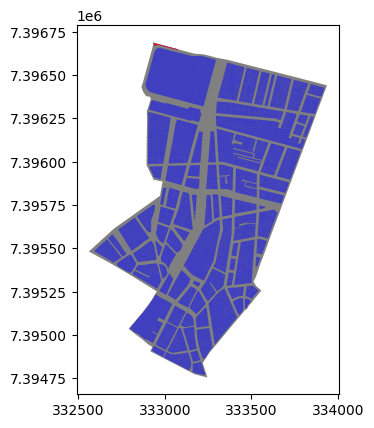

In [61]:
ax = setor.plot(color='grey')
gdf_teste.plot(ax=ax, color='blue',alpha=0.5)
fora.plot(ax=ax, color='red')


In [62]:
setores_sem_lotes = []
def get_lotes_por_setor(cd_setor: str, verbose:bool=False) -> gpd.GeoDataFrame:
    filename = f"lotes_setor_{cd_setor}.parquet"
    subfolder = "lotes_por_setor"
    global setores_sem_lotes
    try:
        # Tenta carregar do cache local
        gdf = load_parquet(filename, subfolder)
        return gdf
        
    except (FileNotFoundError, ValueError):
        # Se não houver cache, inicia a extração por batches para esse setor específico
        lotes_lista = []
        fetcher = GeoSampaWFSFetcher(verbose=verbose)
        
        # Itera pelos lotes filtrando pelo cd_setor_fiscal
        # Nota: no WFS do GeoSampa, o campo na camada lote_cidadao geralmente se chama 'cd_setor_fiscal'
        for batch in fetcher("lote_cidadao", cql_filter=f"cd_setor_fiscal='{cd_setor}'"):
            lotes_lista.extend(batch)

        if len(lotes_lista) == 0:
            setores_sem_lotes.append(cd_setor)
            return gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:31983")  # Retorna um GeoDataFrame vazio com a mesma CRS
            
        # Cria o GeoDataFrame com os dados baixados
        gdf = gpd.GeoDataFrame.from_features(lotes_lista, crs="EPSG:31983")
        
        # Salva o resultado no subfolder específico
        save_parquet(gdf, filename, subfolder)
        
        return gdf

In [63]:
def get_perimetros_zona_setor(gdf_setor:gpd.GeoDataFrame, cd_setor:str)->gpd.GeoDataFrame:

    subfolder = 'perimetros_zona_por_setor'
    filename = f'perimetros_zona_setor_{cd_setor}.parquet'

    try:
        # Tenta carregar do cache local
        gdf = load_parquet(filename, subfolder)
        return gdf
    except (FileNotFoundError):

        minx, miny, maxx, maxy = gdf_setor.total_bounds
        filtro_bbox = f"BBOX(ge_poligono, {minx}, {miny}, {maxx}, {maxy})"

        fetcher = GeoSampaWFSFetcher(verbose=False)
        zoneamento_lista = []
        for batch in fetcher("perimetro_zona_lei_18177_24", cql_filter=filtro_bbox, verbose=True):
            zoneamento_lista.extend(batch)
        if zoneamento_lista:
            gdf_zoneamento = gpd.GeoDataFrame.from_features(zoneamento_lista, crs="EPSG:31983")
            save_parquet(gdf_zoneamento, filename, subfolder)
            return gdf_zoneamento
        else:
            return gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:31983")


In [64]:
def interseccao_zoneamento(gdf_lotes_setor:gpd.GeoDataFrame, gdf_zoneamento:gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf_zoneamento.empty:
        return gpd.GeoDataFrame(columns=gdf_lotes_setor.columns, crs=gdf_lotes_setor.crs)
    
    interseccao = gpd.overlay(gdf_lotes_setor, gdf_zoneamento, how='intersection', keep_geom_type=False)
    interseccao['area_interseccao'] = interseccao.geometry.area
   
    return interseccao

In [65]:
def pipeline():

    file_name = "df_final.parquet"
    subfolder = "resultados_overlay_lotes_zoneamento"
    #verifica se já existe um resultado salvo localmente para evitar refazer toda a pipeline
    try:
        df_final = load_parquet(file_name, subfolder, gdf=False)
        print("Resultado final carregado do cache local.")
        return df_final
    except (FileNotFoundError, ValueError):
        dfs = []
        #itera para cada setor - puxar todos os lotes de uma vez o computador nao aguenta
        for cd_setor in tqdm(list(codigos_setores)):

            #puxa do geosampa os lotes daquele setor fiscal
            gdf_setor = get_lotes_por_setor(cd_setor)
            #verifica se o setor tem lotes cadastrados, se não tiver, pula para o próximo setor
            if gdf_setor.empty:
                print(f"Setor {cd_setor} não possui lotes cadastrados.")
                continue
            
            #obtem a área do polígono do lote para calcular o percentual de interseção depois
            gdf_setor['area_pol_lote'] = gdf_setor.geometry.area

            gdf_zoneamento = get_perimetros_zona_setor(gdf_setor, cd_setor)
            if gdf_zoneamento.empty:
                print(f"Nenhum dado de zoneamento encontrado para o setor {cd_setor}.")
                continue

            interseccao = interseccao_zoneamento(gdf_setor, gdf_zoneamento)
            if interseccao.empty:
                print(f"Não houve interseção entre lotes e zoneamento para o setor {cd_setor}.")
                continue
            
            #selecionando as colunas de interesse para o resultado final
            final = interseccao[[
                'cd_setor_fiscal',
                'cd_quadra_fiscal',
                'cd_lote',
                'cd_condominio',
                'cd_zoneamento_perimetro',
                'an_legislacao_zoneamento',
                'area_pol_lote',
                'area_interseccao',
                'cd_identificador_2'
            ]]
            #renomeando a coluna do identificador do perímetro de zoneamento para facilitar a compreensão do resultado final
            final = final.rename(columns={'cd_identificador_2': 'id_perimetro_zoneamento'})

            dfs.append(final)
            

        #concatena os dfs e atualiza o indice numerico
        df_final = pd.concat(dfs, ignore_index=True)
        df_final = df_final.reset_index(drop=True)


        #obtem o sql e o percentual de área intersectada (é mais otimizado fazer para o df final do que para cada setor individualmente)
        df_final['percentual_interseccao'] = round(df_final['area_interseccao'] / df_final['area_pol_lote'], 3) * 100
        df_final['sql'] = df_final['cd_setor_fiscal'] + '.' + df_final['cd_quadra_fiscal'] + '.' + df_final['cd_lote']

        #salva os dados
        save_parquet(df_final, file_name, subfolder)
        print("Pipeline concluída e resultado salvo no cache local.")
        return df_final


In [66]:
df_final = pipeline()
df_final.head()

 12%|█▏        | 38/309 [00:07<01:03,  4.25it/s]

Setor 217 não possui lotes cadastrados.


 28%|██▊       | 88/309 [00:16<00:48,  4.59it/s]

Setor 250 não possui lotes cadastrados.


 33%|███▎      | 103/309 [00:18<00:43,  4.69it/s]

...

 86%|████████▌ | 265/309 [00:53<00:12,  3.53it/s]

Setor 293 não possui lotes cadastrados.


100%|██████████| 309/309 [01:02<00:00,  4.97it/s]


Pipeline concluída e resultado salvo no cache local.


,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
0,287,005,0010,00,ZMa,2024,244.952910,244.952910,537870,100.0,287.005.0010
1,287,002,0022,00,ZMa,2024,262.557244,262.557244,537875,100.0,287.002.0022
2,287,004,0008,00,ZMa,2024,172.164871,172.164871,537866,100.0,287.004.0008
3,287,005,0003,00,ZMa,2024,253.488401,253.488401,537870,100.0,287.005.0003
4,287,003,0008,00,ZMa,2024,250.609037,250.609037,537867,100.0,287.003.0008


In [67]:
df_final.head()

,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
0,287,005,0010,00,ZMa,2024,244.952910,244.952910,537870,100.0,287.005.0010
1,287,002,0022,00,ZMa,2024,262.557244,262.557244,537875,100.0,287.002.0022
2,287,004,0008,00,ZMa,2024,172.164871,172.164871,537866,100.0,287.004.0008
3,287,005,0003,00,ZMa,2024,253.488401,253.488401,537870,100.0,287.005.0003
4,287,003,0008,00,ZMa,2024,250.609037,250.609037,537867,100.0,287.003.0008


In [68]:
from utils.io.path import output_path
from config import OUTPUT_DIR

if not os.path.exists(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)

df_final.to_parquet(output_path("df_final.parquet", "microdados_lotes_com_zoneamento"))

In [69]:
df_final[df_final['percentual_interseccao']<100].head()

,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
6,287,008,0002,00,ZEPAM,2024,266.566800,0.006155,524824,0.0,287.008.0002
9,287,008,0012,00,ZEPAM,2024,295.804192,0.012036,524824,0.0,287.008.0012
11,287,008,0011,00,ZEPAM,2024,400.904293,0.018279,524824,0.0,287.008.0011
16,287,002,0001,00,ZEPAM,2024,307.290154,0.002878,524824,0.0,287.002.0001
20,287,006,0014,00,ZEIS-1,2024,266.470216,1.274105,520778,0.5,287.006.0014


In [70]:
print(f'Os seguintes setores não retornaram lotes cadastrados no GeoSampa: {setores_sem_lotes}')

Os seguintes setores não retornaram lotes cadastrados no GeoSampa: ['217', '250', '219', '205', '221', '297', '220', '293']
